In [1]:
#!/usr/bin/env python
# coding: utf-8

# =====================================================
# Descriptive analysis of PHC encounters and ILI visits
# =====================================================

# -------------------------
# 1. Import libraries
# -------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import matplotlib.dates as mdates
from datetime import datetime

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import descri_function as desc_fun

import warnings

warnings.filterwarnings('ignore')


# -------------------------
# 2. Load dataset
# -------------------------

df = pd.read_parquet("/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_with_MEM_26_03_2026.parquet")
#aesop_with_MEM_13_03_2026.parquet

df_mem = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/mem_output_26_03_2026.parquet')

# -------------------------
# 4. Select study period
# -------------------------

df = df[(df.year_week >= "2022-42") & (df.year_week <= "2025-32")]

df_mem = df_mem[df_mem.epiyear.isin([2022,2023, 2024,2025])]


# Identify surges intensity

In [2]:
dta_intens = df_mem.groupby(['co_ibge'])[['baseline', 'post_baseline', 'epidemic_threshold',
       'post_threshold', 'low_level', 'medium_level', 'high_level']].max().reset_index()

In [3]:
# FUNCTION TO ASSIGN INTENSITY

def classify_block(values):
    
    # Check from most severe to least
    if (values > high).any():
        return 'very high'
    
    elif (values > med).any():
        return 'high'
    
    elif (values > low).any():
        return 'medium'
    
    elif (values > epi).any():
        return 'low'
    
    elif ((values > base) & (values <= epi)).any():
        return 'very low'
    
    elif (values <= base).any():
        return 'baseline'
    
    return np.nan

In [4]:
warnings.filterwarnings('ignore')

lst = []

for code in df_mem.co_ibge.unique():

    print(code)

    set_muni = df[df.co_ibge == code].copy()
    set_muni_inten = dta_intens[dta_intens.co_ibge == code]

    thresholds = set_muni_inten.iloc[0]

    base = thresholds['baseline'].astype(int)
    epi = thresholds['epidemic_threshold'].astype(int)
    low = thresholds['low_level'].astype(int)
    med = thresholds['medium_level'].astype(int)
    high = thresholds['high_level'].astype(int)
    very_high = thresholds.get('very_high_level', np.inf)  # fallback if missing


    set_muni = set_muni.sort_values(['year_week'])

    # IDENTIFY BLOCKS

    flag = set_muni['mem_surge_01_correct_with_consec']

    # Create block IDs for consecutive 1s
    set_muni['block'] = (flag != flag.shift()).cumsum()

    # Keep only blocks where flag == 1
    set_muni['intensity'] = np.nan


    #  APPLY TO EACH BLOCK

    for block_id, group in set_muni.groupby('block'):
    
        if group['mem_surge_01_correct_with_consec'].iloc[0] != 1:
            continue
    
        values = group['atend_ivas']
    
        intensity_label = classify_block(values)
    
        set_muni.loc[group.index, 'intensity'] = intensity_label

    lst.append(set_muni)


110001
110002
110005
110007
110008
110009
110010
110011
110013
110014
110015
110018
110020
110025
110026
110028
110029
110030
110032
110033
110034
110037
110040
110045
110050
110060
110080
110090
110092
110094
110100
110110
110120
110130
110143
110145
110146
110147
110148
110149
110150
110155
110160
110170
110180
120005
120010
120013
120017
120020
120025
120030
120032
120033
120034
120035
120038
120039
120040
120042
120043
120045
120050
120060
120070
120080
130002
130006
130008
130010
130014
130020
130030
130040
130050
130060
130063
130068
130070
130080
130083
130090
130100
130110
130115
130120
130130
130150
130160
130165
130170
130180
130185
130190
130200
130210
130220
130230
130240
130250
130255
130260
130270
130280
130290
130300
130310
130320
130330
130340
130350
130353
130356
130360
130370
130380
130390
130395
130400
130406
130410
130420
130423
130426
130430
130440
140002
140005
140010
140015
140017
140020
140023
140028
140030
140040
140045
140047
140050
140060
140070
150010
150013

In [5]:
result = pd.concat(lst)

# Now we have only the municipalities valid according the MEM surge.
# We can count surges, in particular their based on intensity

In [6]:
result.columns

Index(['co_uf', 'nm_uf', 'nm_municipio', 'co_ibge', 'epiyear', 'epiweek',
       'year_week', 'atend_totais', 'atend_ivas',
       'mem_surge_01_correct_with_consec', 'warning_final_mem_surge_01',
       'block', 'intensity'],
      dtype='object')

In [7]:
TOTAL_CITIES = 5570

valid_cities = result.co_ibge.nunique()
invalid_cities = TOTAL_CITIES - valid_cities

total_surges = result.warning_final_mem_surge_01.sum()
total_epidemic_weeks = result.mem_surge_01_correct_with_consec.sum()

surges_pre_2025 = result[result.year_week < '2025-01'].warning_final_mem_surge_01.sum()
epi_weeks_pre_2025 = result[result.year_week < '2025-01'].mem_surge_01_correct_with_consec.sum()

surges_2025_on = result[result.year_week >= '2025-01'].warning_final_mem_surge_01.sum()
epi_weeks_2025_on = result[result.year_week >= '2025-01'].mem_surge_01_correct_with_consec.sum()

summary_table = pd.DataFrame({
    "Metric": [
        "Total municipalities",
        "Municipalities with MEM",
        "Municipalities without MEM",
        "Total surge warnings",
        "Total weeks crossing epidemic threshold",
        "Surge warnings before 2025",
        "Total weeks crossing epidemic threshold before 2025",
        "Surge warnings during 2025",
        "Total weeks crossing epidemic threshold during 2025"
    ],
    "Value": [
        TOTAL_CITIES,
        valid_cities,
        invalid_cities,
        total_surges,
        total_epidemic_weeks,
        surges_pre_2025,
        epi_weeks_pre_2025, 
        surges_2025_on,
        epi_weeks_2025_on
    ]
})

summary_table

,Metric,Value
0,Total municipalities,5570
1,Municipalities with MEM,5365
2,Municipalities without MEM,205
3,Total surge warnings,26411
4,Total weeks crossing epidemic threshold,137474
5,Surge warnings before 2025,20646
6,Total weeks crossing epidemic threshold before...,104391
7,Surge warnings during 2025,5765
8,Total weeks crossing epidemic threshold during...,33083


In [8]:
# Overall
intensity_total = (
    result[result.warning_final_mem_surge_01 == 1]
    .intensity
    .value_counts()
    .sort_index()
)

# Before 2025
intensity_pre_2025 = (
    result[(result.year_week < '2025-01') & (result.warning_final_mem_surge_01 == 1)]
    .intensity
    .value_counts()
    .sort_index()
)

# 2025+
intensity_2025_on = (
    result[(result.year_week >= '2025-01') & (result.warning_final_mem_surge_01 == 1)]
    .intensity
    .value_counts()
    .sort_index()
)

# Combine into one table
intensity_table = pd.concat(
    [intensity_total, intensity_pre_2025, intensity_2025_on],
    axis=1
)

intensity_table.columns = [
    "Total",
    "Before 2025",
    "From 2025"
]

intensity_table = intensity_table.fillna(0).astype(int)

intensity_pct = intensity_table.div(intensity_table.sum(axis=0), axis=1) * 100

# Combine counts + %
intensity_pretty = intensity_table.astype(str) + " (" + intensity_pct.round(1).astype(str) + "%)"

intensity_pretty

,Total,Before 2025,From 2025
intensity,,,
high,4041 (15.3%),3309 (16.0%),732 (12.7%)
low,8244 (31.2%),6822 (33.0%),1422 (24.7%)
medium,7605 (28.8%),6107 (29.6%),1498 (26.0%)
very high,6521 (24.7%),4408 (21.4%),2113 (36.7%)


In [9]:
dta = result.groupby(['co_ibge'])['atend_ivas'].sum().reset_index()

#dta.to_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/cities_valid_for_MEM_26_03_2026.parquet')

In [10]:
#list(set(df.co_ibge.unique()) - set(result.co_ibge.unique()))

# Plots

In [11]:
result[(result.warning_final_mem_surge_01 == 1) & (result.intensity == 'very high')].co_ibge.nunique()

4026

In [12]:
code = 530010

set_muni = result[result.co_ibge == code].copy()
set_muni_inten = dta_intens[dta_intens.co_ibge == code]


In [13]:
thresholds = set_muni_inten.iloc[0]

base = thresholds['baseline'].astype(int)
epi = thresholds['epidemic_threshold'].astype(int)
low =  thresholds['low_level'].astype(int)
med = thresholds['medium_level'].astype(int)
high = thresholds['high_level'].astype(int)
very_high = thresholds.get('very_high_level', np.inf)  # fallback if missing

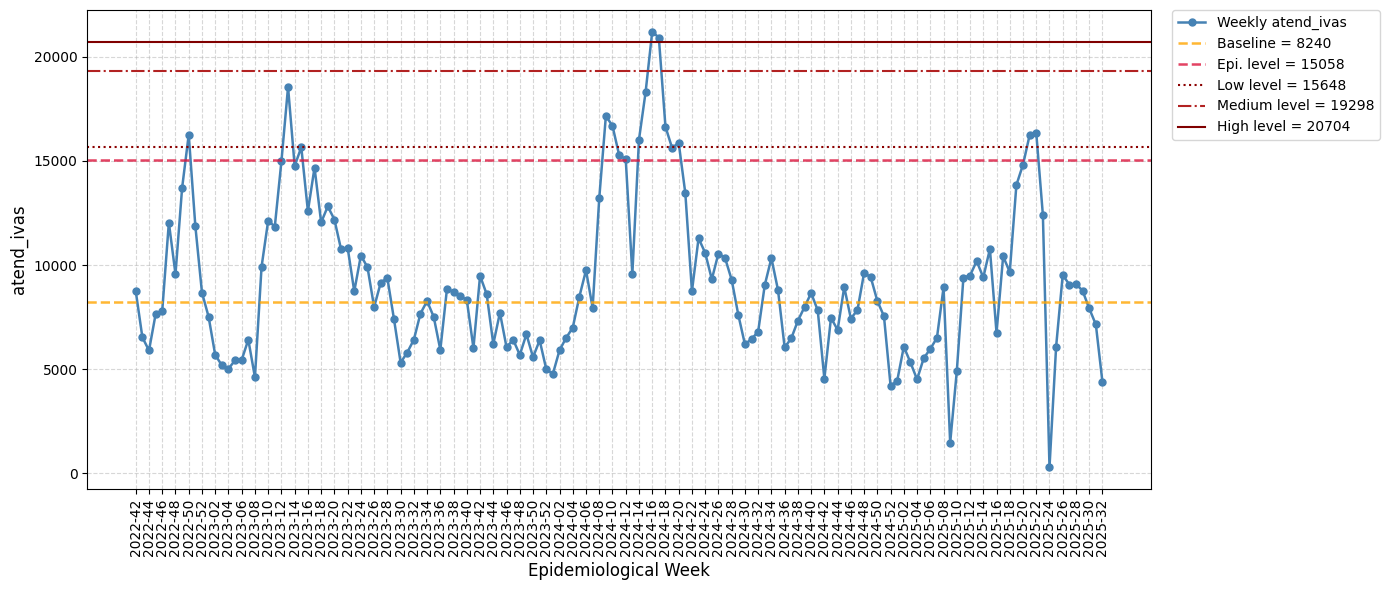

In [14]:
fig, ax = plt.subplots(figsize=(14,6))

# plot weekly values
ax.plot(set_muni["year_week"], set_muni['atend_ivas'], 
        marker="o", markersize=5, linewidth=1.8, color="steelblue", 
        label="Weekly atend_ivas")

# thresholds
ax.axhline(base, color="orange", alpha=0.8, linestyle="--", linewidth=1.8,
           label=f"Baseline = {round(base,0)}")

ax.axhline(epi, color="crimson", alpha=0.8, linestyle="--", linewidth=1.8,
           label=f"Epi. level = {round(epi,0)}")

ax.axhline(low, color="darkred", linestyle=":", linewidth=1.5,
           label=f"Low level = {round(low,0)}")
ax.axhline(med, color="firebrick", linestyle="-.", linewidth=1.5,
           label=f"Medium level = {round(med,0)}")
ax.axhline(high, color="maroon", linestyle="-", linewidth=1.5,
           label=f"High level = {round(high,0)}")

# labels & formatting
ax.set_xlabel("Epidemiological Week", fontsize=12)
ax.set_ylabel("atend_ivas", fontsize=12)
#ax.set_title(f"Season {year}", fontsize=14, fontweight="bold")

# x-axis ticks (reduce clutter)
ax.set_xticks(set_muni["year_week"][::2])  # every 2 weeks
ax.set_xticklabels(set_muni["year_week"][::2], rotation=90)

# grid
ax.grid(True, linestyle="--", alpha=0.5)

# legend outside
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()


# Plot for the whole country

In [15]:
result = result.assign(ones = 1)

In [16]:
df_weekly = result.groupby(['epiyear', 'epiweek','year_week'])[['atend_ivas', 'warning_final_mem_surge_01']].sum().reset_index()

In [17]:
df_weekly.warning_final_mem_surge_01.sum()

26411

In [18]:
result['int_sur'] = np.where(
    result['warning_final_mem_surge_01'] == 1,
    result['intensity'],
    np.nan
)

In [19]:
result['int_sur'].value_counts()

int_sur
low          8244
medium       7605
very high    6521
high         4041
Name: count, dtype: int64

In [20]:
df_intensity = result.groupby(['epiyear', 'epiweek','year_week','int_sur'])['ones'].sum().reset_index()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


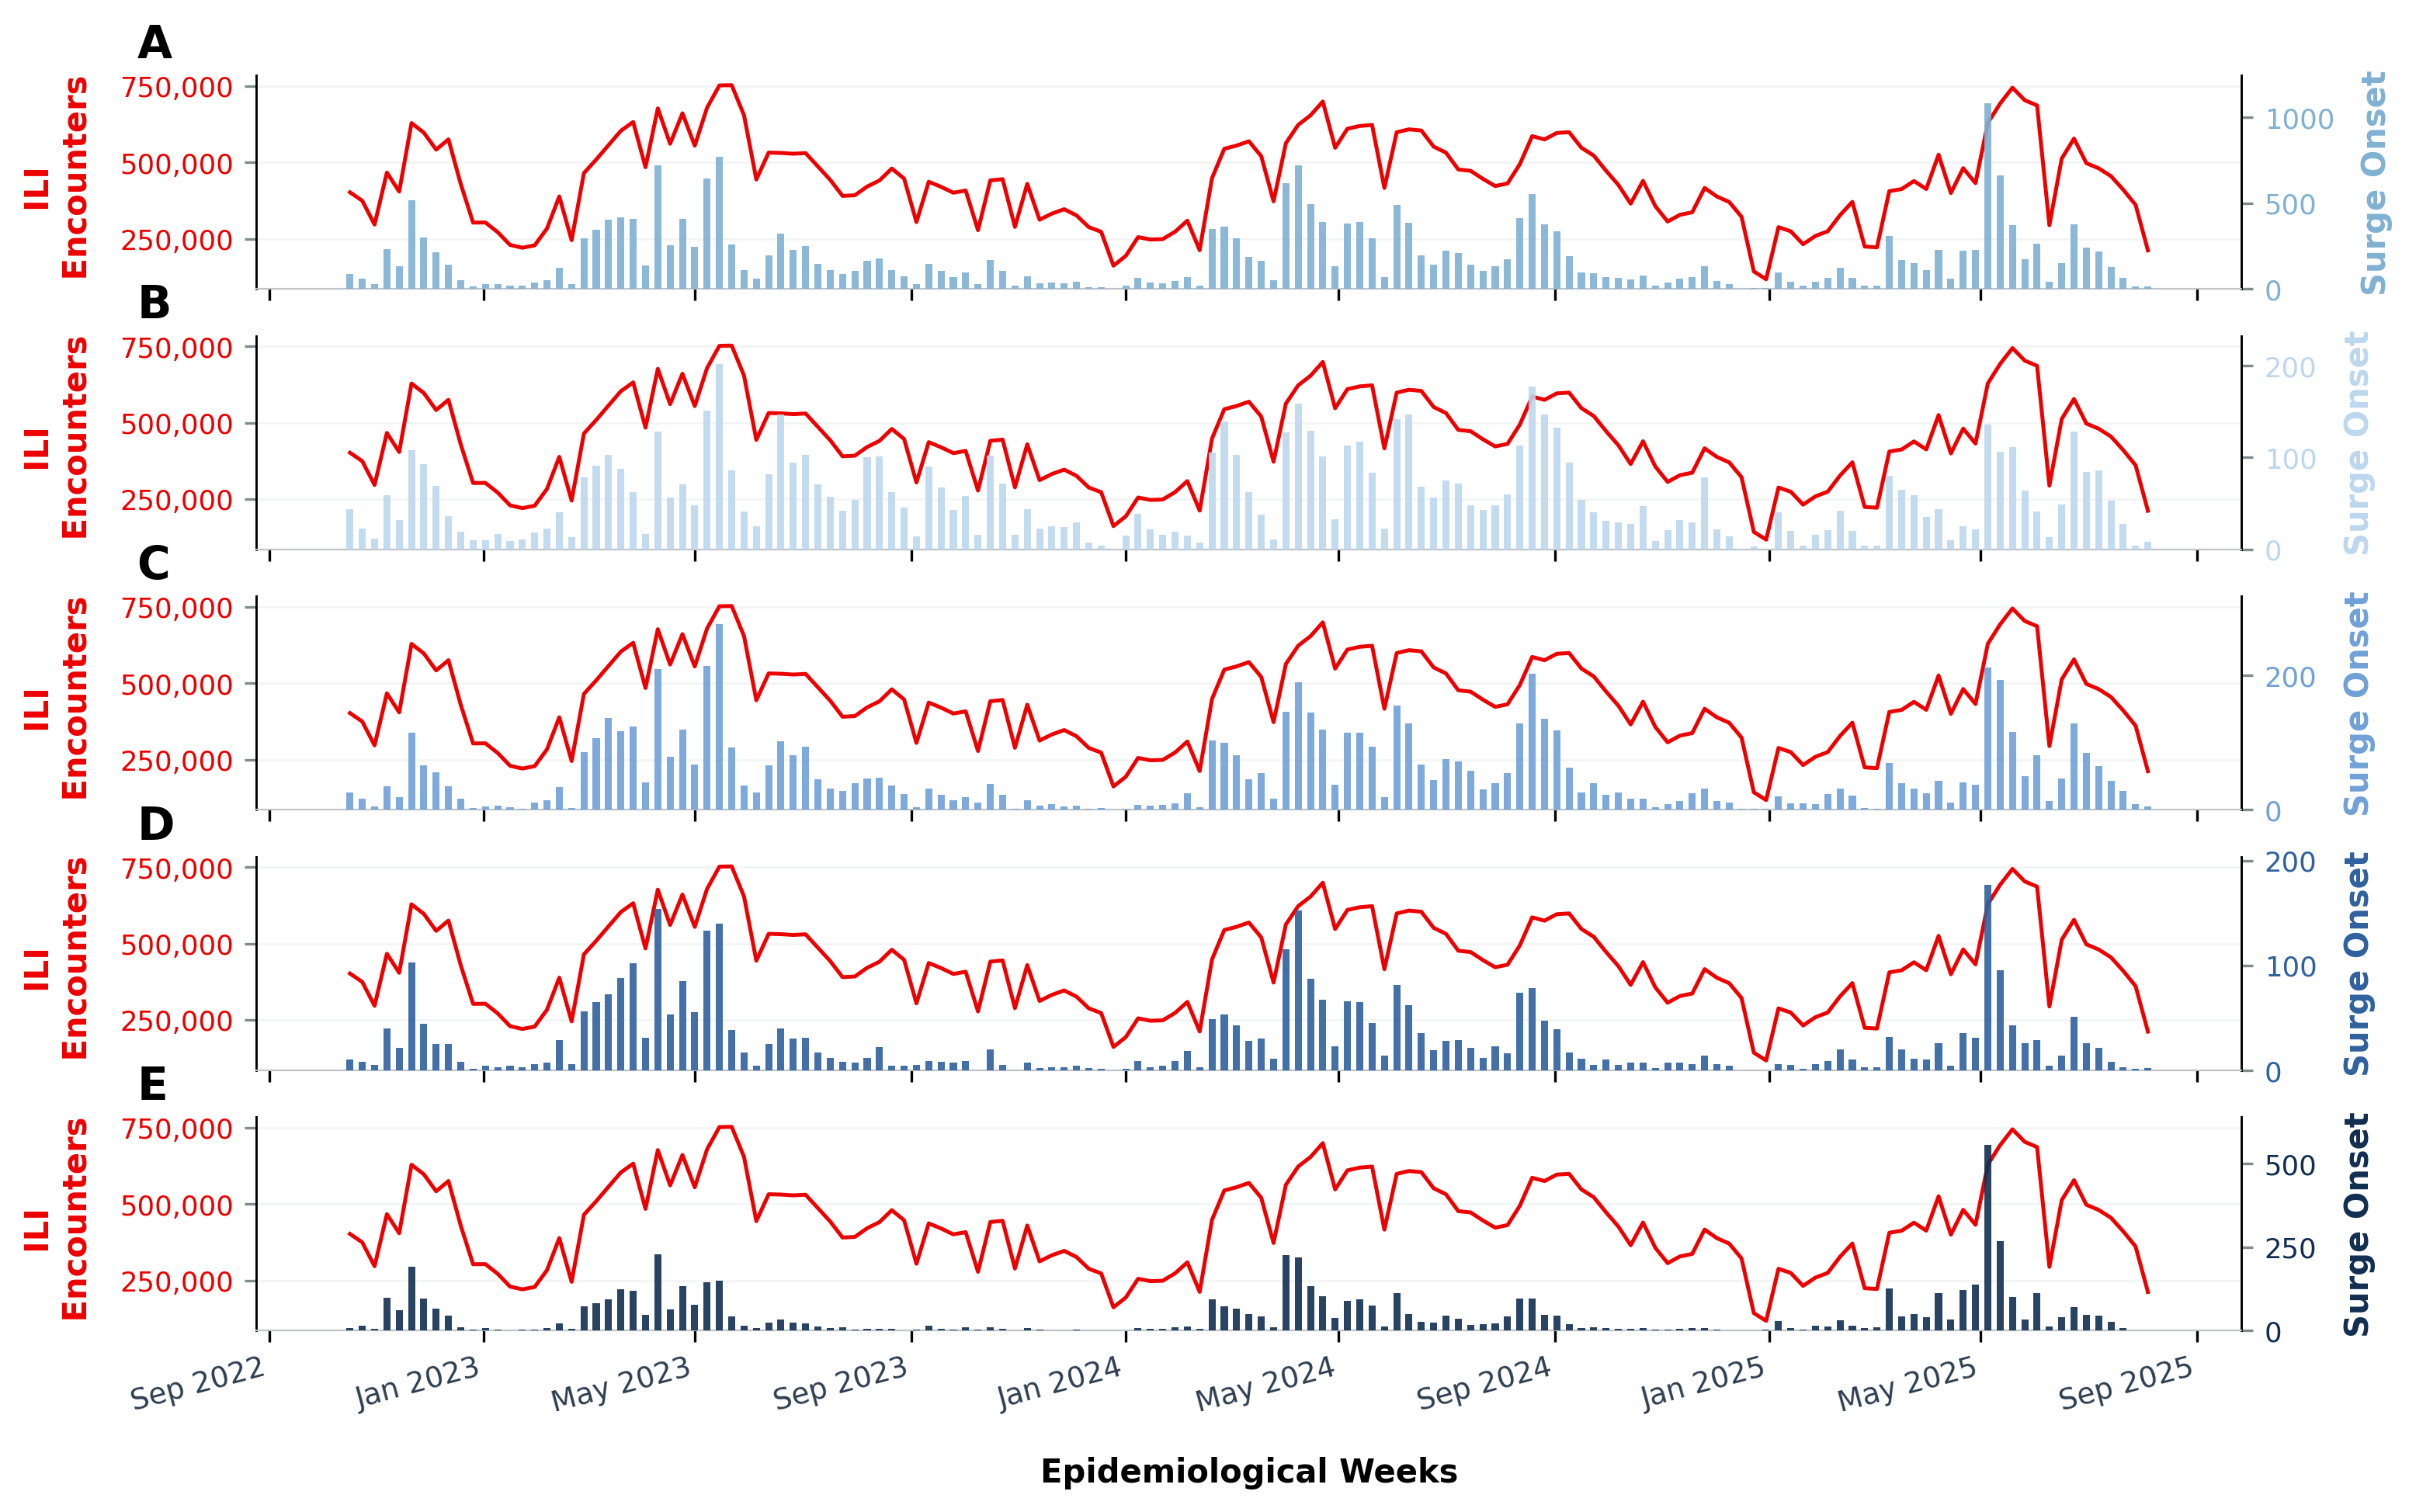

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# --- Convert year_week to datetime (Monday of ISO week) ---
df_weekly["date"] = pd.to_datetime(
    df_weekly["epiyear"].astype(str) + "-W" + df_weekly["epiweek"].astype(str) + "-1",
    format="%G-W%V-%u"
)
df_weekly = df_weekly.sort_values("date")

df_intensity["date"] = pd.to_datetime(
    df_intensity["epiyear"].astype(str) + "-W" + df_intensity["epiweek"].astype(str) + "-1",
    format="%G-W%V-%u"
)
df_intensity = df_intensity.sort_values('date')

# --- 1. Typography & Global Aesthetic Configuration ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Liberation Sans', 'DejaVu Sans'],
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.labelweight': 'bold',
    'axes.linewidth': 0.7
})

# Base Colors
COLOR_LINE = '#ED0000' #'#2C3E50'   # Your preferred Deep Charcoal Slate
GRID_COLOR = '#F2F4F4'   # Your preferred clean background tint

#LANCET_BLUE = '#00468B'
#LANCET_RED = '#ED0000'
#BAR_COLOR = '#80B1D3' 

# Sequential Intensity Colors for the Bars (Light -> Dark/Deep)
BAR_COLORS = [
    '#80B1D3',           # Panel A: Total Surges (Your original preferred blue)
    '#BDD7EE',           # Panel B: Low Intensity 
    '#70A1D7',           # Panel C: Medium Intensity
    '#2E619E',           # Panel D: High Intensity
    '#112E51'            # Panel E: Very High Intensity (Deep Midnight Navy)
]

# --- 2. Figure Geometry Configuration ---
fig, axes = plt.subplots(5, 1, figsize=(11, 7), sharex=True, dpi=300)
intensity_order = ['low', 'medium', 'high', 'very high']
panel_labels = ['A', 'B', 'C', 'D', 'E']

# --- 3. Plotting Engine Loop ---
for i in range(5):
    ax = axes[i]
    current_bar_color = BAR_COLORS[i]  # Pulls the corresponding color intensity row
    
    if i == 0:
        curve_data = df_weekly['atend_ivas']
        surge_data = df_weekly['warning_final_mem_surge_01']
        plot_dates = df_weekly['date']
    else:
        level = intensity_order[i-1]
        sub = df_intensity[df_intensity['int_sur'] == level]
        plot_data = pd.merge(df_weekly[['date', 'atend_ivas']], 
                             sub[['date', 'ones']], on='date', how='left').fillna(0)
        curve_data = plot_data['atend_ivas']
        surge_data = plot_data['ones']
        plot_dates = plot_data['date']

    # --- A. Background Trend Line (Left Y-Axis) ---
    ax.plot(plot_dates, curve_data, color=COLOR_LINE, linewidth=1.2, label='ILI \n Encounters', zorder=2)
    ax.set_ylabel('ILI \n Encounters', color=COLOR_LINE, labelpad=8)
    ax.tick_params(axis='y', labelcolor=COLOR_LINE, colors='#7F8C8D', labelsize=8.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    # Grid lines fixed to left axis framework
    ax.yaxis.grid(True, linestyle='-', color=GRID_COLOR, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)

    # --- B. Foreground Surge Bars (Right Y-Axis) ---
    ax_twin = ax.twinx()
    
    # Dynamically tracking the color spectrum update
    ax_twin.bar(plot_dates, surge_data, color=current_bar_color, alpha=0.9, 
                width=4, edgecolor='none', label='Surge Onset', zorder=3)
    ax_twin.set_ylabel('Surge Onset', color=current_bar_color, labelpad=8)
    ax_twin.tick_params(axis='y', labelcolor=current_bar_color, colors='#7F8C8D', labelsize=8.5)

    if surge_data.max() > 0:
        ax_twin.set_ylim(0, surge_data.max() * 1.15)

    # --- C. Panel Lettering Labels ---
    ax.text(-0.06, 1.04, panel_labels[i], transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='bottom', ha='left', color='#000000')

    # --- D. Spine Border Polish ---
    for frame in [ax, ax_twin]:
        frame.spines['top'].set_visible(False)
        frame.spines['left'].set_visible(False) if frame == ax_twin else None
        frame.spines['right'].set_visible(False) if frame == ax else None
        frame.spines['bottom'].set_color('#BDC3C7')
        frame.spines['bottom'].set_linewidth(0.5)

# --- 4. Shared X-Axis Timeline Configuration ---
bottom_ax = axes[4]
bottom_ax.set_xlabel('Epidemiological Weeks', fontsize=10, fontweight='bold', labelpad=12)

bottom_ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 5, 9]))
bottom_ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(bottom_ax.get_xticklabels(), rotation=15, ha='right', color='#2C3E50')

# --- 5. Layout Alignment Execution ---
fig.align_ylabels(axes)
plt.subplots_adjust(hspace=0.22)

# Save vector outputs
plt.savefig('/home/juliane.oliveira/workspace/aesop-detection-models/figures/fig1_elegant.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.savefig('/home/juliane.oliveira/workspace/aesop-detection-models/figures/fig1_elegant.eps', format='eps', bbox_inches='tight')

plt.show()

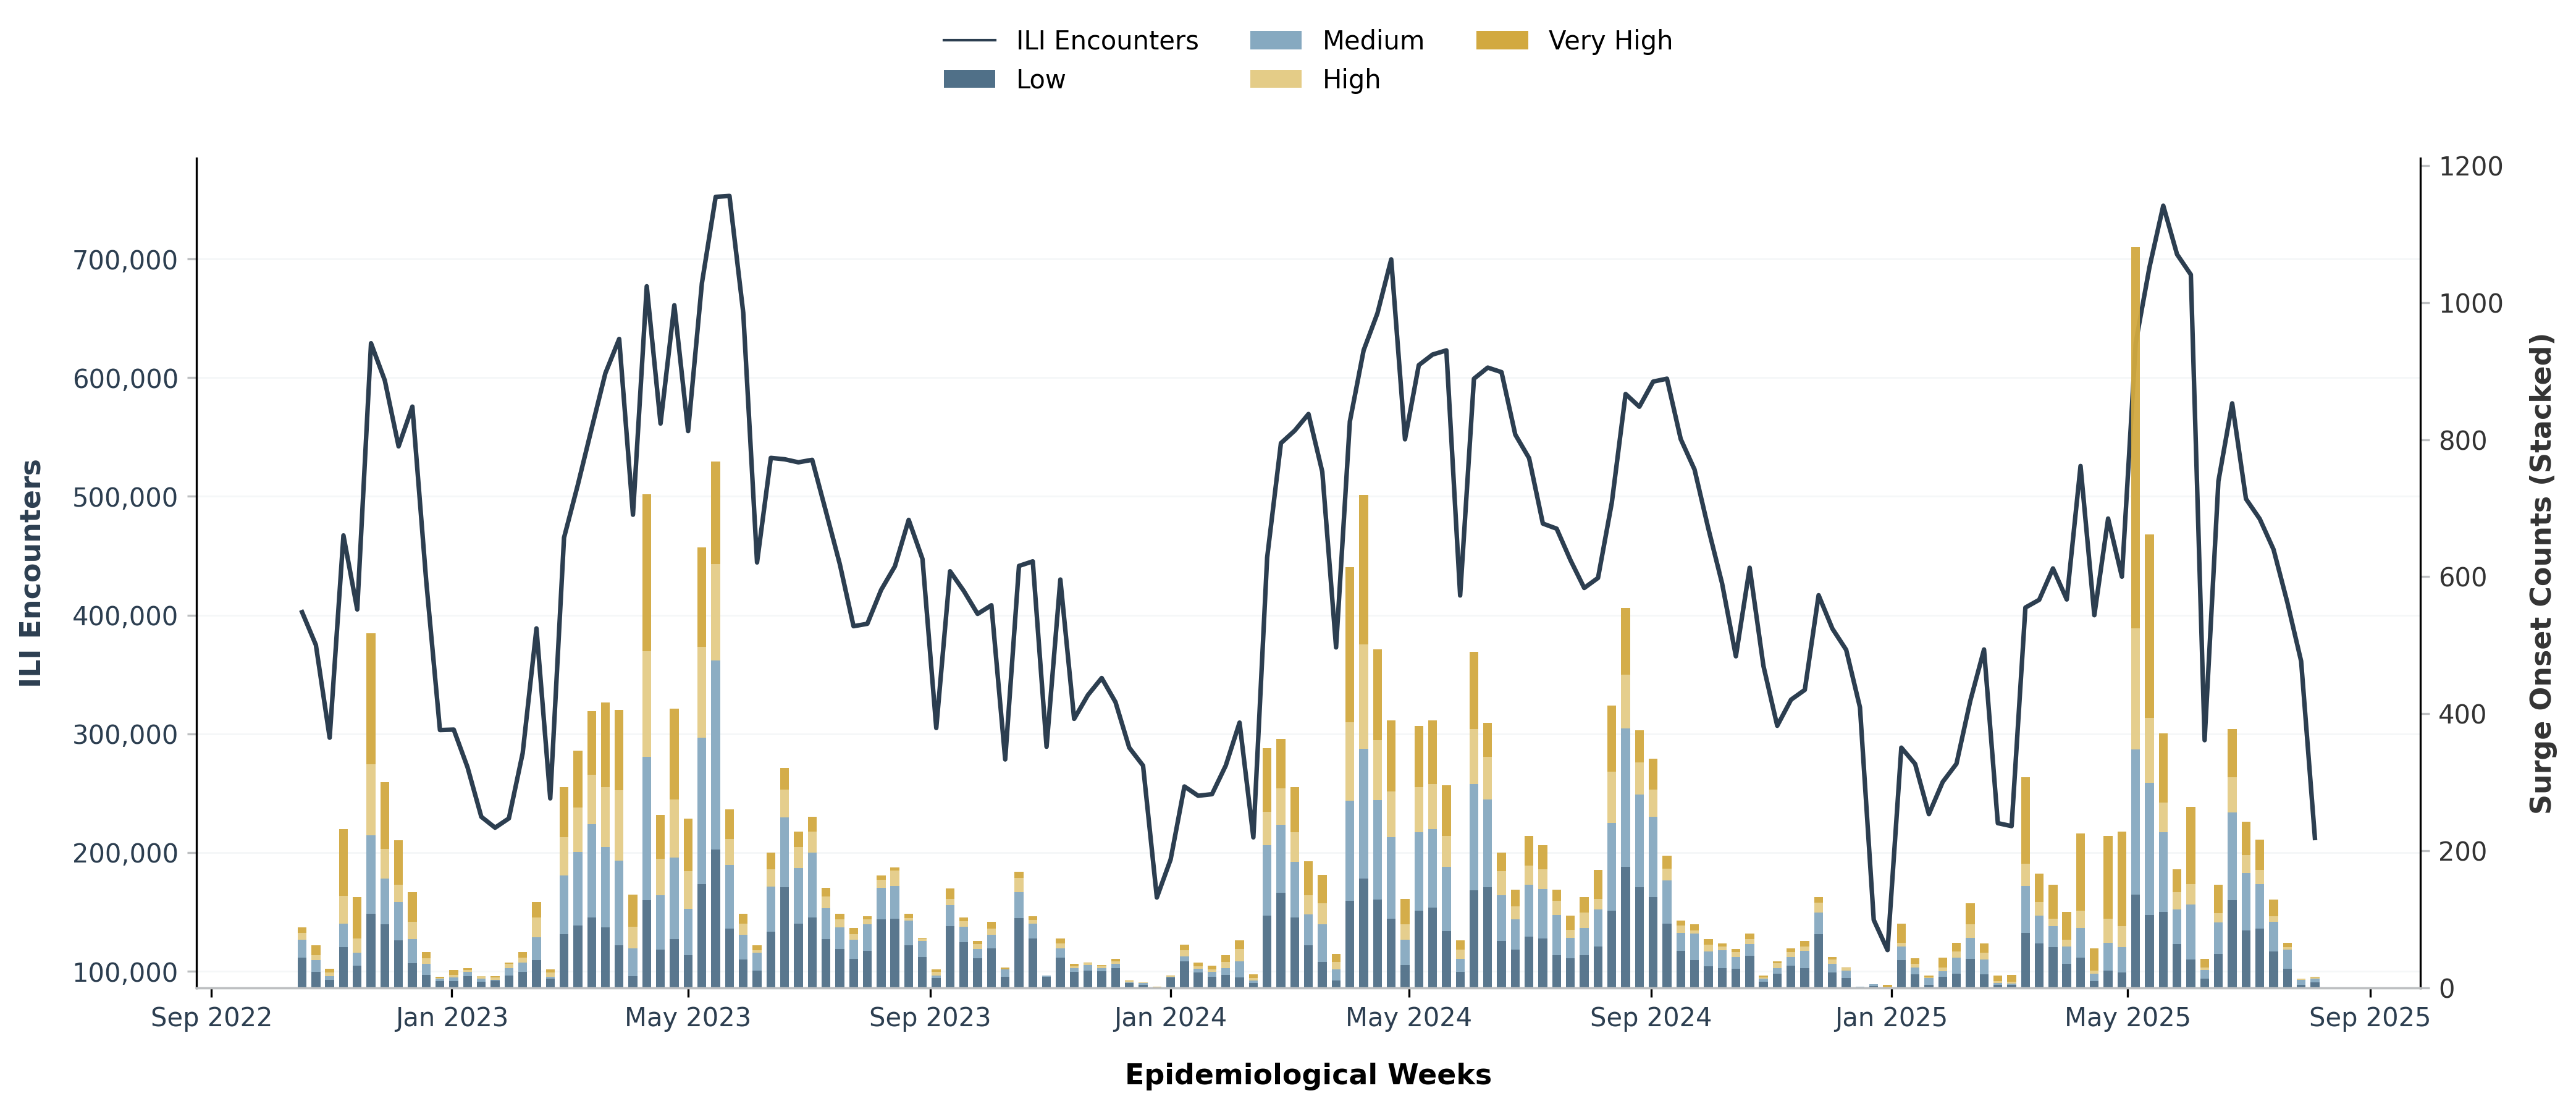

In [23]:
# --- 1. Data Aggregation & Alignment ---
for df in [df_weekly, df_intensity]:
    if "date" not in df.columns:
        df["date"] = pd.to_datetime(
            df["epiyear"].astype(str) + "-W" + df["epiweek"].astype(str) + "-1",
            format="%G-W%V-%u"
        )

df_int_pivot = df_intensity.pivot(index='date', columns='int_sur', values='ones').fillna(0)
df_master = df_weekly[['date', 'atend_ivas']].merge(df_int_pivot, on='date', how='left').fillna(0)

intensity_order = ['low', 'medium', 'high', 'very high']
for col in intensity_order:
    if col not in df_master.columns:
        df_master[col] = 0.0

# --- 2. Typography & Theme Configuration ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Liberation Sans', 'DejaVu Sans'],
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.labelweight': 'bold',
    'axes.linewidth': 0.8
})

COLOR_LINE = '#2C3E50'   # Deep Charcoal Slate for ILI
GRID_COLOR = '#F5F7F8'   # Clean, ultra-faint layout grid
GREY_SPINE = '#bdbfc1'   # Tailored edge borders

PALETTE = {
    'low': '#507088',       # Slate Blue
    'medium': '#86a9c0',    # Soft Light Slate
    'high': '#e4cc87',      # Warm Soft Gold
    'very high': '#d2a940'  # Deep Rich Gold
}

# --- 3. Plot Construction ---
fig, ax = plt.subplots(figsize=(14, 6.5), dpi=300)

# A. Left Axis: ILI Encounters Trend
ax.plot(df_master['date'], df_master['atend_ivas'], color=COLOR_LINE, 
        linewidth=1.75, label='ILI Encounters', zorder=2)
ax.set_ylabel('ILI Encounters', color=COLOR_LINE, labelpad=10)
ax.tick_params(axis='y', labelcolor=COLOR_LINE, colors=GREY_SPINE)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.yaxis.grid(True, linestyle='-', color=GRID_COLOR, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

# B. Right Axis: Stacked Surge Proportions
ax_twin = ax.twinx()

bottom_stack = None
for tier in intensity_order:
    ax_twin.bar(
        df_master['date'], df_master[tier], bottom=bottom_stack,
        color=PALETTE[tier], alpha=0.95, width=4.5, edgecolor='none',
        label=f'{tier.capitalize()} Intensity Surge'
    )
    if bottom_stack is None:
        bottom_stack = df_master[tier].copy()
    else:
        bottom_stack += df_master[tier]

ax_twin.set_ylabel('Surge Onset Counts (Stacked)', color='#333333', labelpad=10)
ax_twin.tick_params(axis='y', labelcolor='#333333', colors=GREY_SPINE)

if bottom_stack is not None:
    ax_twin.set_ylim(0, bottom_stack.max() * 1.12)

# --- 4. Shared Axis Styling & Labels ---
ax.set_xlabel('Epidemiological Weeks', fontsize=11, fontweight='bold', labelpad=12)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 5, 9]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=0, ha='center', color=COLOR_LINE)

for frame in [ax, ax_twin]:
    frame.spines['top'].set_visible(False)
    frame.spines['left'].set_visible(False) if frame == ax_twin else None
    frame.spines['right'].set_visible(False) if frame == ax else None
    frame.spines['bottom'].set_color(GREY_SPINE)

# --- 5. UPDATED: Top Center 2-Line Legend ---
legend_elements = [
    Line2D([0], [0], color=COLOR_LINE, linewidth=1, label='ILI Encounters'),
    Patch(facecolor=PALETTE['low'], label='Low'),
    Patch(facecolor=PALETTE['medium'], label='Medium'),
    Patch(facecolor=PALETTE['high'], label='High'),
    Patch(facecolor=PALETTE['very high'], label='Very High')
]

# Shifts the legend above the figure boundary safely
ax.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.05),  # Centered horizontally, sitting right over the plot ceiling
    ncol=3,                      # 3 columns creates a clean 2-row block layout
    frameon=False,               # Removed box border for an elegant editorial feel
    fontsize=10
)

# Added rect layout padding to prevent the top legend text from clipping off the export canvas
plt.tight_layout(rect=[0, 0, 1, 0.94])

# Save final outputs
plt.savefig('/home/juliane.oliveira/workspace/aesop-detection-models/figures/fig1_unified.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.savefig('/home/juliane.oliveira/workspace/aesop-detection-models/figures/fig1_unified.png', format='png', bbox_inches='tight', dpi=300)

plt.show()

# Test if the count of a intensity tipe is significant different from previous years

In [61]:
dta2 = df_intensity[(df_intensity.epiweek >= 1) & (df_intensity.epiweek <= 32)].groupby(['epiyear','int_sur'])['ones'].sum().reset_index()#.ones.sum()

In [72]:
dta2.groupby('epiyear')['ones'].sum().reset_index().ones.to_list()

[7403, 7375, 5765]

In [96]:
dta2.ones.sum()

20543

In [100]:
dta3 = dta2.groupby('int_sur')['ones'].sum().reset_index()

dta3 = dta3.assign(per = round(dta3.ones*100/dta2.ones.sum(),1))

dta3

,int_sur,ones,per
0,high,3290,16.0
1,low,5795,28.2
2,medium,5997,29.2
3,very high,5461,26.6


In [95]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.proportion import proportions_ztest

for value in ['low', 'medium', 'high', 'very high']:

    data = dta2[dta2.int_sur == value]

    data = data.rename(columns={'ones': value})

    data = data.assign(total = dta2.groupby('epiyear')['ones'].sum().reset_index().ones.to_list())

    data = data[['epiyear', value, 'total']]

    # Proportion
    data['prop'] = data[value] / data['total']
    data['prop_per'] = round(data['prop']*100,1)

    # 95% CI (Wilson is robust)
    ci_low, ci_high = proportion_confint(
        data[value],
        data['total'],
        method='wilson'
    )

    data['ci_low'] = ci_low
    data['ci_high'] = ci_high

    print(data)

    subset = data[data.epiyear.isin([2023, 2025])].sort_values('epiyear')

    counts = subset[value].values
    totals = subset['total'].values

    stat, pval = proportions_ztest(counts[::-1], totals[::-1])

    print(value," 2025 vs 2023 p =", pval)

    subset = data[data.epiyear.isin([2024, 2025])].sort_values('epiyear')

    counts = subset[value].values
    totals = subset['total'].values

    stat, pval = proportions_ztest(counts[::-1], totals[::-1])

    print(value," 2025 vs 2024 p =", pval)

   epiyear   low  total      prop  prop_per    ci_low   ci_high
1     2023  2138   7403  0.288802      28.9  0.278590  0.299233
5     2024  2235   7375  0.303051      30.3  0.292667  0.313640
9     2025  1422   5765  0.246661      24.7  0.235705  0.257955
low  2025 vs 2023 p = 6.603137881981758e-08
low  2025 vs 2024 p = 8.232519825643321e-13
    epiyear  medium  total      prop  prop_per    ci_low   ci_high
2      2023    2340   7403  0.316088      31.6  0.305594  0.326772
6      2024    2159   7375  0.292746      29.3  0.282471  0.303236
10     2025    1498   5765  0.259844      26.0  0.248686  0.271322
medium  2025 vs 2023 p = 1.840240756780417e-12
medium  2025 vs 2024 p = 2.9663993248394682e-05
   epiyear  high  total      prop  prop_per    ci_low   ci_high
0     2023  1337   7403  0.180602      18.1  0.172006  0.189530
4     2024  1221   7375  0.165559      16.6  0.157251  0.174216
8     2025   732   5765  0.126973      12.7  0.118626  0.135817
high  2025 vs 2023 p = 4.875982752039